Business Understanding
        ↓
Data Collection
        ↓
Dataset Understanding
        ↓
Data Cleaning
(Remove corrupted / invalid images)
        ↓
Train / Validation / Test Split
        ↓
Image Transformations
        ↓
Create Dataset
(ImageFolder)
        ↓
Create DataLoaders
        ↓
Visualize Images
        ↓
Baseline CNN
(Custom CNN Architecture)
        ↓
Choose Loss Function
        ↓
Choose Optimizer
        ↓
Training Loop
        ↓
Validation
        ↓
Hyperparameter Tuning
(Optional)
        ↓
Model Evaluation
        ↓
        ┌──────────────────────────────┐
        │      Improve Performance     │
        └──────────────┬───────────────┘
                       ↓
               Transfer Learning
                       ↓
          Choose Pretrained Model
      (ResNet / EfficientNet / MobileNet)
                       ↓
             Modify Classifier
                       ↓
             Freeze / Unfreeze Layers
                       ↓
              Fine-Tuning
                       ↓
              Model Evaluation
                       ↓
             Compare Models
          Custom CNN vs Pretrained
                       ↓
               Select Best Model
                       ↓
              Save Trained Model
                       ↓
             Inference / Prediction
                       ↓
              Deployment (Streamlit)
                       ↓
                GitHub + README

In [1]:
import torch
import os
from PIL import Image
import matplotlib.pyplot as plt

In [20]:
import torch

print("PyTorch Version:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch Version: 2.11.0+cu128
CUDA Available: True
Using Device: cuda
GPU: Tesla T4


<b>Project Goal :</b>

The goal of this project is to build a deep learning image classification system using CNNs (Convolutional Neural Networks) that can analyze chest X-ray images and classify them into predefined categories such as Normal and Pneumonia.

The project will demonstrate how computer vision and deep learning can be used to extract visual patterns from medical images and perform automated image classification.

<mark>This project is for educational and machine-learning demonstration purposes only and is not intended for medical diagnosis or clinical decision-making.

In [3]:
#next stpe: Data Collection

from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import os

print(os.listdir("/content/drive/MyDrive"))

['Colab Notebooks', 'Shipsense', '"I am restarting my study journey after a 6.5-yea....gsheet', 'Google AI Studio', 'chest_xray_dataset']


In [5]:
import os

print(os.listdir("/content/drive/MyDrive/chest_xray_dataset"))

['NORMAL ', 'PNEUMONIA ']


In [6]:
dataset_path = r"/content/drive/MyDrive/chest_xray_dataset"

normal_path = os.path.join(dataset_path, "NORMAL ")
pneumonia_path = os.path.join(dataset_path, "PNEUMONIA ")

print("NORMAL images:", len(os.listdir(normal_path)))
print("PNEUMONIA images:", len(os.listdir(pneumonia_path)))

NORMAL images: 1583
PNEUMONIA images: 4273


#dataset understanding

In this step, we will analyze the structure and characteristics of the
Chest X-Ray dataset before performing data cleaning and splitting.

We will inspect:

- Number of images in each class
- Total number of images
- Image dimensions
- Image channels
- File formats
- Sample images
- Class distribution

In [7]:
#no. of images in all classes


dataset_path = r"/content/drive/MyDrive/chest_xray_dataset"

normal_path = os.path.join(dataset_path, "NORMAL ")
pneumonia_path = os.path.join(dataset_path, "PNEUMONIA ")

print("NORMAL images:", len(os.listdir(normal_path)))
print("PNEUMONIA images:", len(os.listdir(pneumonia_path)))

NORMAL images: 1583
PNEUMONIA images: 4273


In [8]:
#total number of images

len(os.listdir(normal_path)) + len(os.listdir(pneumonia_path))

5856

In [9]:
#specifying the folder paths

dataset_path = r"/content/drive/MyDrive/chest_xray_dataset"

normal_path = os.path.join(dataset_path, "NORMAL ")
pneumonia_path = os.path.join(dataset_path, "PNEUMONIA ")

In [10]:
import os

print(os.getcwd())

/content


In [11]:
import os

print(os.listdir(dataset_path))

print(os.listdir(normal_path))

print(os.listdir(pneumonia_path))

['NORMAL ', 'PNEUMONIA ']
['NORMAL-4199443-0002.jpeg', 'NORMAL-4240389-0001.jpeg', 'NORMAL-4241389-0001.jpeg', 'NORMAL-4190414-0001.jpeg', 'NORMAL-4178256-0001.jpeg', 'NORMAL-4486854-0001.jpeg', 'NORMAL-4316614-0001.jpeg', 'NORMAL-4499436-0001.jpeg', 'NORMAL-4418958-0001.jpeg', 'NORMAL-4496165-0001.jpeg', 'NORMAL-4358449-0001.jpeg', 'NORMAL-4507677-0002.jpeg', 'NORMAL-4320287-0001.jpeg', 'NORMAL-4500184-0001.jpeg', 'NORMAL-447225-0001.jpeg', 'NORMAL-4315572-0001.jpeg', 'NORMAL-4418958-0003.jpeg', 'NORMAL-4418958-0004.jpeg', 'NORMAL-4358449-0002.jpeg', 'NORMAL-4464072-0001.jpeg', 'NORMAL-4316614-0002.jpeg', 'NORMAL-4418958-0002.jpeg', 'NORMAL-4377146-0001.jpeg', 'NORMAL-4363211-0001.jpeg', 'NORMAL-4340661-0001.jpeg', 'NORMAL-4320287-0002.jpeg', 'NORMAL-4447575-0001.jpeg', 'NORMAL-445267-0001.jpeg', 'NORMAL-4421061-0001.jpeg', 'NORMAL-4317334-0001.jpeg', 'NORMAL-4507677-0001.jpeg', 'NORMAL-4513268-0001.jpeg', 'NORMAL-4649665-0001.jpeg', 'NORMAL-4515478-0001.jpeg', 'NORMAL-4515478-0002.jp

In [12]:
#checking dimensions of images


from PIL import Image
import os

image_name = os.listdir(normal_path)[0]

image_path = os.path.join(normal_path, image_name)

with Image.open(image_path) as img:
    print("Image dimensions:", img.size)

Image dimensions: (1728, 1619)


In [13]:
#lets inspect a image from the dataset

normal_images = os.listdir(normal_path)

image_1 = os.path.join(normal_path, normal_images[727])

print(image_1)

/content/drive/MyDrive/chest_xray_dataset/NORMAL /NORMAL-8416635-0001.jpeg


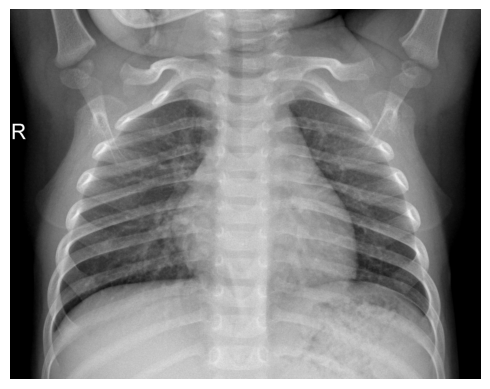

In [14]:
import matplotlib.pyplot as plt

img = Image.open(image_1)

plt.imshow(img, cmap="gray")
plt.axis("off")
plt.show()

In [15]:
#last: lets check image channels

with Image.open(image_path) as img:
    print("Image mode:", img.mode)

Image mode: L


# analysis about image channels


L → 1 channel

RGB → 3 channels

RGBA → 4 channels

<mark>so , our dataset images containes only 1 channel / grayscale

Formats = .jpeg

#data understanding done now next step is : Data Cleaning (Remove corrupted / invalid images)


<mark>In this step, we will identify corrupted or invalid image files
before splitting the dataset into training, validation, and testing sets.

We will detect:


Corrupted JPEG files

Files that cannot be opened

Zero-byte/invalid image files

Files with invalid image content

Non-image files accidentally present in the folders

In [16]:
#removing file that are not jpeg from normal folder


normal_files = os.listdir(normal_path)

count = 0

for file in normal_files:

    if not file.lower().endswith((".jpg", ".jpeg", ".png")):
        count = count+1
        print("Non-image file:", file)

print(f"{count} non-image files found")

0 non-image files found


In [17]:
#same with pneumonia folder


pneumonia_files = os.listdir(pneumonia_path)


count = 0

for file in pneumonia_files:
  if not file.lower().endswith(('.jpg','.jpeg','.png')):
    count = count +1
    print("Non image files ",file)


print(count)

0


In [18]:
# now lets find Zero-byte files

os.path.getsize(r'/content/drive/MyDrive/chest_xray_dataset/NORMAL /NORMAL-8416635-0001.jpeg')

#from normal folder

normal_files = os.listdir(normal_path)
count = 0
for file in normal_files:

    file_path = os.path.join(normal_path, file)
    if os.path.getsize(file_path) == 0:
        print("Zero-byte file:", file)
        count = count + 1

print(count)


0


In [19]:
#same with pneumonia folder

pneumonia_files = os.listdir(pneumonia_path)

count = 0

for file in pneumonia_files:
  file_path = os.path.join(pneumonia_path,file)

  if os.path.getsize(file_path) == 0:
    print("Zero-byte file:",file)
    count = count + 1

print(count)


0



<b> Data Cleaning Done Now next step is :Train / Validation / Test Split

In [19]:
# Train / Validation / Test Split


# We'll use:

# 70% → Train
# 15% → Validation
# 15% → Test


In [23]:
#lets provides all folder paths

output_path = "/content/drive/MyDrive/chest_xray_splitted"

dataset_path = r"/content/drive/MyDrive/chest_xray_dataset"

normal_path = os.path.join(dataset_path, "NORMAL ")
pneumonia_path = os.path.join(dataset_path, "PNEUMONIA ")


In [24]:
#after creating paths we will make folders such as "train", "validation", "test"

for split in ["train", "validation", "test"]:

    for category in ["NORMAL", "PNEUMONIA"]:

        os.makedirs(
            os.path.join(output_path, split, category),
            exist_ok=True
        )

In [25]:
#now folders are empty we need to split images as well

train_ratio = 0.70
val_ratio = 0.15
test_ratio = 0.15


normal_files = os.listdir(normal_path)
pneumonia_files = os.listdir(pneumonia_path)

#shuffle them for better accuracy uaing random

import random

random.shuffle(normal_files)
random.shuffle(pneumonia_files)

In [27]:
train_end = int(len(normal_files) * train_ratio)
val_end = train_end + int(len(normal_files) * val_ratio)
test_end = val_end + int(len(normal_files) * test_ratio)

print(train_end)
print(val_end)
print(test_end)

1108
1345
1582
